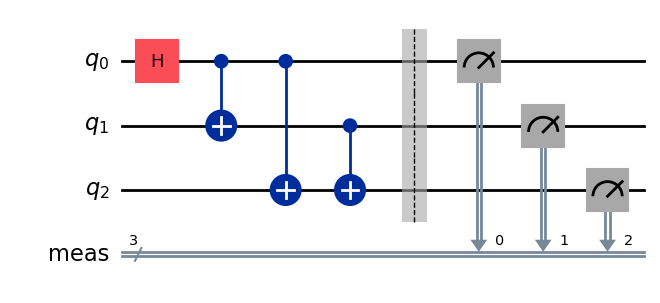

In [73]:
# !pip install qiskit
from qiskit import QuantumCircuit

# Create a quantum circuit with 3 qubits
qc = QuantumCircuit(3)

# Apply one Hadamard gate and CNOT gates
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(1, 2)

qc.measure_all()
# Visualize the circuit
qc.draw("mpl")

Measurement counts: {'011': 509, '000': 515}


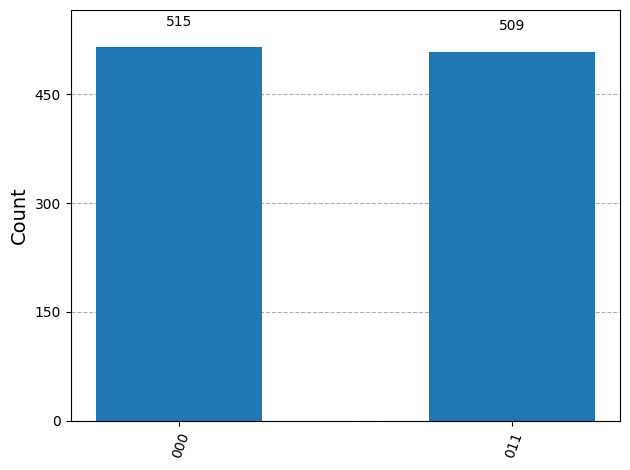

In [74]:
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Run the measured circuit and show outcomes
backend = BasicSimulator()
tqc = transpile(qc, backend)
result = backend.run(tqc, shots=1024).result()
counts = result.get_counts()

print("Measurement counts:", counts)
fig = plot_histogram(counts)
display(fig)
plt.close(fig)

Compiled circuit depth: 10
Compiled circuit gates: OrderedDict([('cx', 6), ('measure', 3), ('rz', 2), ('rx', 1), ('barrier', 1)])


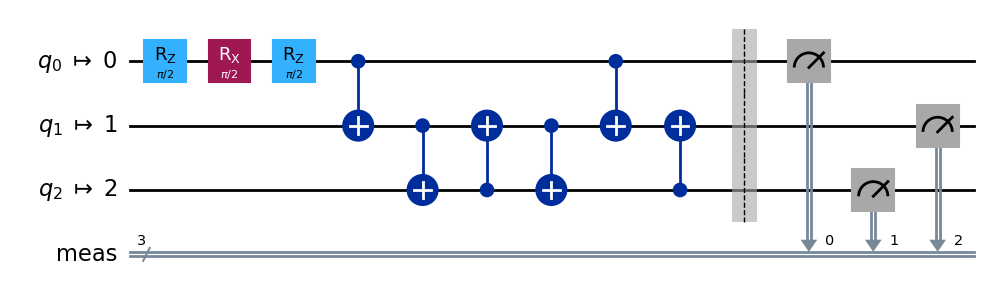

In [4]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
import numpy as np

# 3-qubit hardware with limited connectivity: 0 <-> 1 <-> 2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Native gate set for compilation (no H gate)
basis_gates = ["rz", "rx", "cx", "measure"]

# Self-contained compile circuit (same logic as design)
# Original logical design: H(0), CX(0,1), CX(0,2), CX(1,2)
qc_for_compile = QuantumCircuit(3)

# Replace H with Rx/Rz decomposition: H ≡ Rz(pi/2) -> Rx(pi/2) -> Rz(pi/2)
qc_for_compile.rz(np.pi / 2, 0)
qc_for_compile.rx(np.pi / 2, 0)
qc_for_compile.rz(np.pi / 2, 0)

qc_for_compile.cx(0, 1)
qc_for_compile.cx(0, 2)
qc_for_compile.cx(1, 2)
qc_for_compile.measure_all()

compiled_qc = transpile(
    qc_for_compile,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=1,
    initial_layout=[0, 1, 2],   # keep q0->0, q1->1, q2->2
    layout_method="trivial",    # do not search for a different qubit layout
)

print("Compiled circuit depth:", compiled_qc.depth())
print("Compiled circuit gates:", compiled_qc.count_ops())
compiled_qc.draw("mpl")

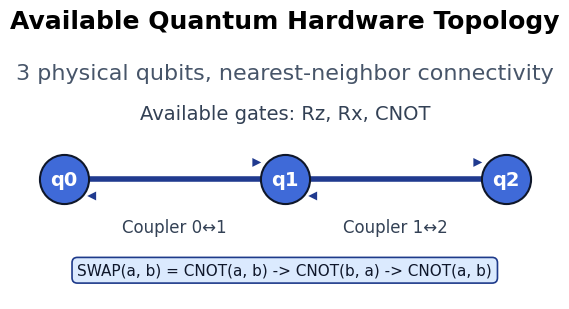

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Assumed hardware topology: 3 qubits with limited connectivity 0 <-> 1 <-> 2
positions = {0: (0.0, 0.0), 1: (1.6, 0.0), 2: (3.2, 0.0)}
connections = [(0, 1), (1, 2)]

fig, ax = plt.subplots(figsize=(6, 3.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f7f9fc")

# Draw couplers (line + bidirectional arrows)
for left, right in connections:
    x1, y1 = positions[left]
    x2, y2 = positions[right]

    ax.plot([x1, x2], [y1, y2], color="#203a8f", linewidth=4, solid_capstyle="round", zorder=1)

    arrow_fwd = FancyArrowPatch((x1 + 0.15, y1 + 0.07), (x2 - 0.15, y2 + 0.07),
                                arrowstyle="-|>", mutation_scale=16, lw=0, color="#203a8f", zorder=2)
    arrow_bwd = FancyArrowPatch((x2 - 0.15, y2 - 0.07), (x1 + 0.15, y1 - 0.07),
                                arrowstyle="-|>", mutation_scale=16, lw=0, color="#203a8f", zorder=2)
    ax.add_patch(arrow_fwd)
    ax.add_patch(arrow_bwd)

# Draw qubit nodes
for qubit, (x, y) in positions.items():
    ax.scatter(x, y, s=1250, color="#3f6ad8", edgecolors="#0f172a", linewidths=1.5, zorder=3)
    ax.text(x, y, f"q{qubit}", color="white", ha="center", va="center", fontsize=14, weight="bold", zorder=4)

# Annotate couplers
ax.text(0.8, -0.2, "Coupler 0↔1", ha="center", va="center", fontsize=12, color="#334155")
ax.text(2.4, -0.2, "Coupler 1↔2", ha="center", va="center", fontsize=12, color="#334155")

ax.set_title("Available Quantum Hardware Topology", fontsize=18, weight="bold", pad=14)
ax.text(1.6, 0.42, "3 physical qubits, nearest-neighbor connectivity", ha="center", fontsize=16, color="#475569")
ax.text(1.6, 0.25, "Available gates: Rz, Rx, CNOT", ha="center", fontsize=14, color="#334155")

swap_note = "SWAP(a, b) = CNOT(a, b) -> CNOT(b, a) -> CNOT(a, b)"
ax.text(1.6, -0.38, swap_note, ha="center", va="center", fontsize=11, color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#dbeafe", edgecolor="#1e3a8a", linewidth=1.2))

ax.set_xlim(-0.2, 3.4)
ax.set_ylim(-0.5, 0.55)
ax.axis("off")
plt.tight_layout()
plt.show()

## Decomposition of the Hadamard gate `H`

The initial design keeps `H` explicitly. For compilation (where `H` is unavailable), we use an equivalent Rx/Rz decomposition.

A standard identity is:

$$
H = e^{i\pi/2}\; R_z\left(\frac{\pi}{2}\right)\; R_x\left(\frac{\pi}{2}\right)\; R_z\left(\frac{\pi}{2}\right)
$$

- The global phase $e^{i\pi/2}$ does not affect measurement probabilities.
- Operationally, we replace `H` with `Rz(π/2) -> Rx(π/2) -> Rz(π/2)`.
- This is why the compiled circuit uses `rz` and `rx` instead of a direct `h` gate.

Reference gate: H


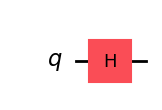

Decomposition: Rz(π/2) -> Rx(π/2) -> Rz(π/2)


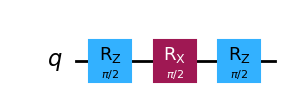

Equivalent up to global phase: True
Max |ΔU|: 2.22e-16


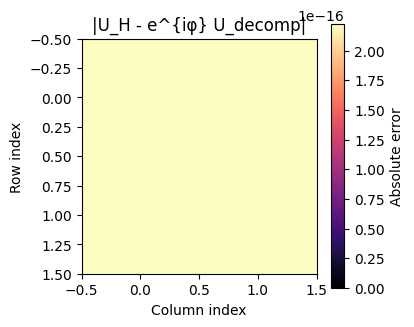

In [77]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Compare ONLY the H gate with its Rx/Rz decomposition
h_ref = QuantumCircuit(1)
h_ref.h(0)

h_decomp = QuantumCircuit(1)
h_decomp.rz(np.pi / 2, 0)
h_decomp.rx(np.pi / 2, 0)
h_decomp.rz(np.pi / 2, 0)

print("Reference gate: H")
display(h_ref.draw("mpl"))
print("Decomposition: Rz(π/2) -> Rx(π/2) -> Rz(π/2)")
display(h_decomp.draw("mpl"))

# Unitary equivalence check up to global phase
u_ref = Operator(h_ref).data
u_decomp = Operator(h_decomp).data

inner = np.vdot(u_decomp.flatten(), u_ref.flatten())
phase = inner / np.abs(inner) if np.abs(inner) > 0 else 1.0
u_aligned = phase * u_decomp
delta = u_ref - u_aligned

is_equivalent = np.allclose(delta, 0, atol=1e-10)
print(f"Equivalent up to global phase: {is_equivalent}")
print(f"Max |ΔU|: {np.max(np.abs(delta)):.2e}")

# Visualize absolute matrix difference (2x2)
fig, ax = plt.subplots(figsize=(4.2, 3.5))
im = ax.imshow(np.abs(delta), cmap="magma", vmin=0)
ax.set_title("|U_H - e^{iφ} U_decomp|")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
fig.colorbar(im, ax=ax, label="Absolute error")
plt.tight_layout()
plt.show()

## Decomposition of the SWAP gate `SWAP`

Like the Hadamard section, we compare the gate with an equivalent decomposition used during compilation.

A standard identity is:

$$
\mathrm{SWAP}(a,b)=\mathrm{CNOT}(a,b)\;\mathrm{CNOT}(b,a)\;\mathrm{CNOT}(a,b)
$$

- This decomposition uses only CNOT operations.
- It explains why routing/compilation can replace a SWAP with three CNOT gates.
- Below, we verify unitary equivalence numerically.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Compare ONLY the SWAP gate with its 3-CNOT decomposition
swap_ref = QuantumCircuit(2)
swap_ref.swap(0, 1)

swap_decomp = QuantumCircuit(2)
swap_decomp.cx(0, 1)
swap_decomp.cx(1, 0)
swap_decomp.cx(0, 1)

print("Reference gate: SWAP")
display(swap_ref.draw("mpl"))
print("Decomposition: CNOT(0,1) -> CNOT(1,0) -> CNOT(0,1)")
display(swap_decomp.draw("mpl"))

# Unitary equivalence check up to global phase
u_ref = Operator(swap_ref).data
u_decomp = Operator(swap_decomp).data

inner = np.vdot(u_decomp.flatten(), u_ref.flatten())
phase = inner / np.abs(inner) if np.abs(inner) > 0 else 1.0
u_aligned = phase * u_decomp
delta = u_ref - u_aligned

is_equivalent = np.allclose(delta, 0, atol=1e-10)
print(f"Equivalent up to global phase: {is_equivalent}")
print(f"Max |ΔU|: {np.max(np.abs(delta)):.2e}")

# Visualize absolute matrix difference (4x4)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(np.abs(delta), cmap="magma", vmin=0)
ax.set_title("|U_SWAP - e^{iφ} U_decomp|")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
fig.colorbar(im, ax=ax, label="Absolute error")
plt.tight_layout()
plt.show()